In [15]:
import torch
import time
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, NullFormatter

torch._dynamo.config.recompile_limit = 128

def runBenchmark(
        func_provider,     # provides a function fused x times
        inputs,            # inputs to the function (tensor on device)
        iterations,        # number of iterations to run per instance
        single_call_flops, # number of flops per single call
        fusion_range,      # inclusive [start, end] range of fusion to test
        steps,             # number of steps to test between start and end
        verbose=False,
        needOutputs=False):
    if verbose:
        print(f"Running benchmark")
    outputs = None
    if needOutputs:
        outputs = torch.empty_like(inputs)

    def get_log_splits(start, end, n):
        r = [int(start * (end/start)**(i/n)) for i in range(n+1)]
        for i in range(1,len(r)):
            if(r[i] <= r[i-1]):
                r[i] = r[i-1] + 1
        return r

    fusion_values = get_log_splits(fusion_range[0], fusion_range[1], steps)
    stats = []
    for fusion_value in fusion_values:
        func = func_provider(fusion_value)
        # warm up
        f = torch.compile(func)
        #f = torch.jit.trace(func)

        for _ in range(5): 
            if needOutputs:
                f(outputs, inputs)
            else:
                f(inputs)

        torch.cuda.synchronize()
        start = time.time()
        for _ in range(iterations):
            if needOutputs:
                f(outputs, inputs)
            else:
                f(inputs)
        torch.cuda.synchronize()
        end = time.time()

        t_iter = (end - start) / iterations
        iter_per_sec = 1 / t_iter
        flops = iter_per_sec * single_call_flops * fusion_value * inputs.shape[0]
        bytes_per_second = iter_per_sec * inputs.numel() * inputs.element_size() * 2

        stats.append((
            fusion_value,
            iter_per_sec,
            flops * 1e-12,             # TFLOPS
            bytes_per_second * 1e-9))    # GB/s
        if verbose:
            print(f"Fusion: {fusion_value}, Iter/sec: {iter_per_sec:.3f}, TFLOPS: {flops * 1e-12:.2f}, Mem Gb/s: {bytes_per_second*1e-9:.2f}")
    return stats

def plot_stats(name, stats):
    def make_plot(filename, name, value_name, x_data, y_data):
        plt.plot(x_data, y_data, label=name)
        plt.xlabel("Fuses")
        plt.ylabel(value_name)
        plt.legend()
        plt.xscale("log", base=2)
        ax = plt.gca()
        ax.set_xticks(x_data)
        ax.xaxis.set_major_formatter(ScalarFormatter())
        ax.xaxis.set_minor_formatter(NullFormatter())
        ax.ticklabel_format(axis="y", style="plain")
        plt.show()
        #plt.savefig(f"{filename}_{name}.png")

    make_plot(name, "Compute", "FLOPS (TF/s)", [f[0] for f in stats], [f[2] for f in stats])
    make_plot(name, "Memory", "Mem B/W (GB/s)", [f[0] for f in stats], [f[3] for f in stats])
    

Running benchmark
Fusion: 1, Iter/sec: 621.962, TFLOPS: 0.04, Mem Gb/s: 333.91
Fusion: 2, Iter/sec: 627.363, TFLOPS: 0.08, Mem Gb/s: 336.81
Fusion: 3, Iter/sec: 621.035, TFLOPS: 0.13, Mem Gb/s: 333.42
Fusion: 4, Iter/sec: 629.389, TFLOPS: 0.17, Mem Gb/s: 337.90
Fusion: 5, Iter/sec: 621.372, TFLOPS: 0.21, Mem Gb/s: 333.60
Fusion: 6, Iter/sec: 627.761, TFLOPS: 0.25, Mem Gb/s: 337.03
Fusion: 7, Iter/sec: 619.761, TFLOPS: 0.29, Mem Gb/s: 332.73
Fusion: 8, Iter/sec: 621.500, TFLOPS: 0.33, Mem Gb/s: 333.67
Fusion: 12, Iter/sec: 621.680, TFLOPS: 0.50, Mem Gb/s: 333.76
Fusion: 16, Iter/sec: 621.001, TFLOPS: 0.67, Mem Gb/s: 333.40
Fusion: 22, Iter/sec: 621.628, TFLOPS: 0.92, Mem Gb/s: 333.73
Fusion: 30, Iter/sec: 625.140, TFLOPS: 1.26, Mem Gb/s: 335.62
Fusion: 41, Iter/sec: 665.787, TFLOPS: 1.83, Mem Gb/s: 357.44
Fusion: 56, Iter/sec: 664.775, TFLOPS: 2.50, Mem Gb/s: 356.90
Fusion: 77, Iter/sec: 665.632, TFLOPS: 3.44, Mem Gb/s: 357.36
Fusion: 105, Iter/sec: 621.806, TFLOPS: 4.38, Mem Gb/s: 333.

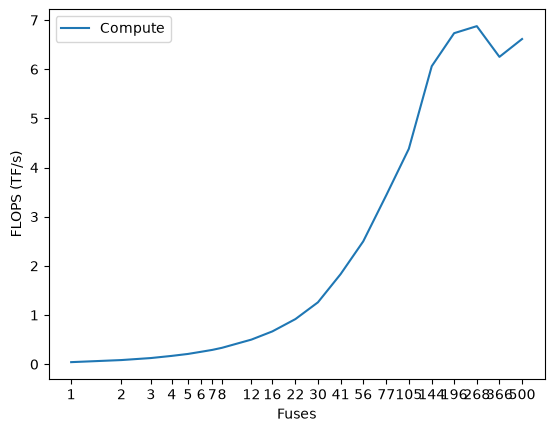

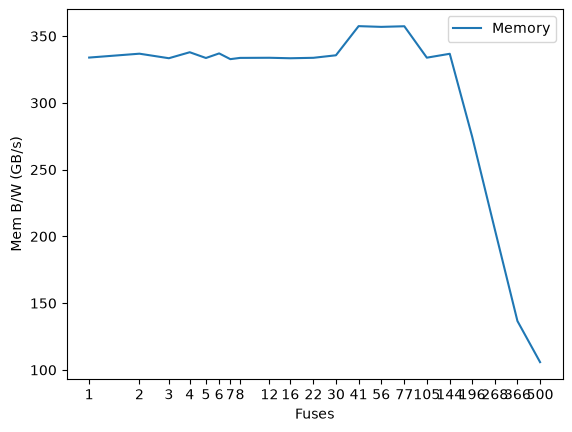

In [ ]:
# REGULAR FMUL

def mul_f_provider(repeat):
    def f(x):
        for _ in range(repeat):
            x = x * 3
        return x
    return f

plot_stats(
    "gpu_mul",
    runBenchmark(
        func_provider=mul_f_provider,
        inputs=torch.randn(2**26, dtype=torch.float32).cuda(),
        iterations=100,
        single_call_flops=1,
        fusion_range=[1, 500],
        steps=20,
        verbose=True))

Running benchmark
Fusion: 1, Iter/sec: 629.399, TFLOPS: 0.08, Mem Gb/s: 337.91
Fusion: 2, Iter/sec: 621.141, TFLOPS: 0.17, Mem Gb/s: 333.47
Fusion: 3, Iter/sec: 628.109, TFLOPS: 0.25, Mem Gb/s: 337.21
Fusion: 4, Iter/sec: 619.982, TFLOPS: 0.33, Mem Gb/s: 332.85
Fusion: 5, Iter/sec: 627.516, TFLOPS: 0.42, Mem Gb/s: 336.90
Fusion: 6, Iter/sec: 619.483, TFLOPS: 0.50, Mem Gb/s: 332.58
Fusion: 7, Iter/sec: 628.079, TFLOPS: 0.59, Mem Gb/s: 337.20
Fusion: 8, Iter/sec: 621.881, TFLOPS: 0.67, Mem Gb/s: 333.87
Fusion: 12, Iter/sec: 621.951, TFLOPS: 1.00, Mem Gb/s: 333.91
Fusion: 16, Iter/sec: 620.190, TFLOPS: 1.33, Mem Gb/s: 332.96
Fusion: 22, Iter/sec: 627.521, TFLOPS: 1.85, Mem Gb/s: 336.90
Fusion: 30, Iter/sec: 623.595, TFLOPS: 2.51, Mem Gb/s: 334.79
Fusion: 41, Iter/sec: 621.815, TFLOPS: 3.42, Mem Gb/s: 333.83
Fusion: 56, Iter/sec: 624.534, TFLOPS: 4.69, Mem Gb/s: 335.29
Fusion: 77, Iter/sec: 624.453, TFLOPS: 6.45, Mem Gb/s: 335.25
Fusion: 105, Iter/sec: 622.480, TFLOPS: 8.77, Mem Gb/s: 334.

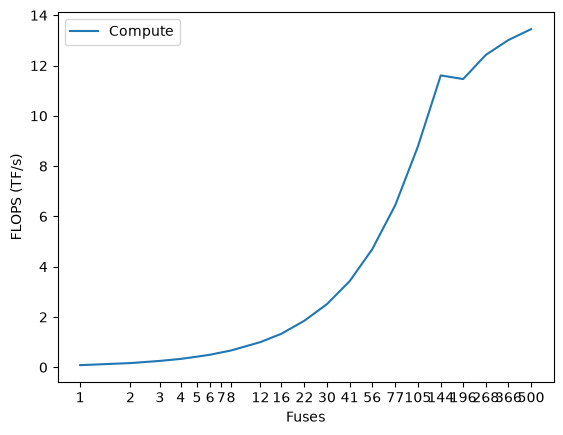

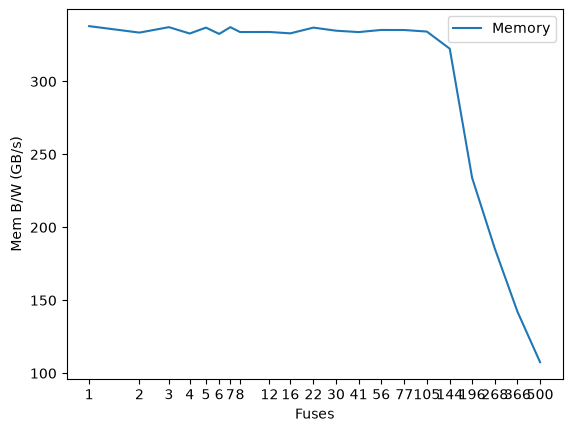

In [ ]:
# REGULAR FFMA - 2 flops multiply + accumulate

def mul_f_provider(repeat):
    def f(x):
        for _ in range(repeat):
            x = x * 3 + 1
        return x
    return f

plot_stats(
    "gpu_mul",
    runBenchmark(
        func_provider=mul_f_provider,
        inputs=torch.randn(2**26, dtype=torch.float32).cuda(),
        iterations=100,
        single_call_flops=2,
        fusion_range=[1, 500],
        steps=20,
        verbose=True))

Running benchmark
Fusion: 1, Iter/sec: 1051.014, TFLOPS: 0.56, Mem Gb/s: 282.13
Fusion: 2, Iter/sec: 1232.705, TFLOPS: 1.32, Mem Gb/s: 330.90
Fusion: 3, Iter/sec: 1234.737, TFLOPS: 1.99, Mem Gb/s: 331.45
Fusion: 4, Iter/sec: 1236.962, TFLOPS: 2.66, Mem Gb/s: 332.04
Fusion: 5, Iter/sec: 1232.962, TFLOPS: 3.31, Mem Gb/s: 330.97
Fusion: 6, Iter/sec: 1235.876, TFLOPS: 3.98, Mem Gb/s: 331.75
Fusion: 7, Iter/sec: 1213.591, TFLOPS: 4.56, Mem Gb/s: 325.77
Fusion: 8, Iter/sec: 1209.043, TFLOPS: 5.19, Mem Gb/s: 324.55
Fusion: 12, Iter/sec: 1123.054, TFLOPS: 7.24, Mem Gb/s: 301.47
Fusion: 16, Iter/sec: 974.638, TFLOPS: 8.37, Mem Gb/s: 261.63
Fusion: 22, Iter/sec: 799.739, TFLOPS: 9.45, Mem Gb/s: 214.68
Fusion: 30, Iter/sec: 654.328, TFLOPS: 10.54, Mem Gb/s: 175.64
Fusion: 41, Iter/sec: 511.938, TFLOPS: 11.27, Mem Gb/s: 137.42
Fusion: 56, Iter/sec: 404.199, TFLOPS: 12.15, Mem Gb/s: 108.50
Fusion: 77, Iter/sec: 301.431, TFLOPS: 12.46, Mem Gb/s: 80.91
Fusion: 105, Iter/sec: 227.519, TFLOPS: 12.83, M

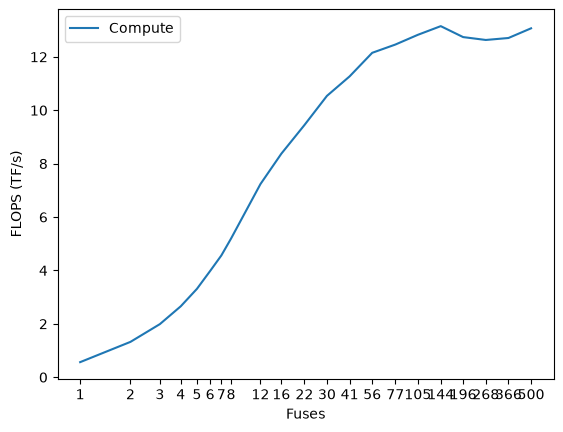

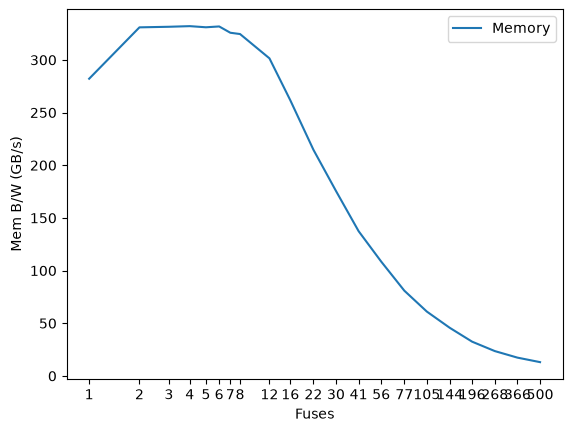

In [36]:
# REGULAR HFMA2 - 2 FMA on 16 bit floats, 4 flops effectively

from torch.utils.cpp_extension import load

hfma2 = load(name="hfma2", sources=["/home/nevidomy/work/ml_learning/benchmarks/hfma2.cu"],
         extra_cuda_cflags=["-O3", "-lineinfo"], verbose=True)

def mul_f_provider(repeat):
    def f(out, x):
        return hfma2.packed(out, x, repeat)
    return f

plot_stats(
    "gpu_mul",
    runBenchmark(
        func_provider=mul_f_provider,
        inputs=torch.randn(2**26, dtype=torch.float16).cuda(),
        iterations=100,
        single_call_flops=8,
        fusion_range=[1, 500],
        steps=20,
        verbose=True,
        needOutputs=True))

[1/2] /usr/local/cuda-12.8/bin/nvcc -MD -MF hfma2.cuda.o.d -DTORCH_EXTENSION_NAME=hfma2_v10 -DTORCH_API_INCLUDE_EXTENSION_H -isystem /home/nevidomy/venvs/ml/lib/python3.12/site-packages/torch/include -isystem /home/nevidomy/venvs/ml/lib/python3.12/site-packages/torch/include/torch/csrc/api/include -isystem /usr/local/cuda-12.8/include -isystem /usr/include/python3.12 -D__CUDA_NO_HALF_OPERATORS__ -D__CUDA_NO_HALF_CONVERSIONS__ -D__CUDA_NO_BFLOAT16_CONVERSIONS__ -D__CUDA_NO_HALF2_OPERATORS__ --expt-relaxed-constexpr -gencode=arch=compute_86,code=compute_86 -gencode=arch=compute_86,code=sm_86 --compiler-options '-fPIC' -O3 -lineinfo -std=c++17 -c /home/nevidomy/work/ml_learning/benchmarks/hfma2.cu -o hfma2.cuda.o 
[2/2] c++ hfma2.cuda.o -shared -L/home/nevidomy/venvs/ml/lib/python3.12/site-packages/torch/lib -lc10 -lc10_cuda -ltorch_cpu -ltorch_cuda -ltorch -ltorch_python -L/usr/local/cuda-12.8/lib64 -lcudart -o hfma2_v10.so
Running benchmark


/home/nevidomy/venvs/ml/lib/python3.12/site-packages/torch/_dynamo/variables/functions.py:2082: UserWarning: Dynamo does not know how to trace the builtin `hfma2_v10.pybind11_detail_function_record_v1_system_libstdcpp_gxx_abi_1xxx_use_cxx11_abi_1.scalar.` This function is either a Python builtin (e.g. _warnings.warn) or a third-party C/C++ Python extension (perhaps created with pybind).
If it is a Python builtin, please file an issue on GitHub so the PyTorch team can add support for it and see the next case for a workaround.
If it is a third-party C/C++ Python extension, please either wrap it into a PyTorch-understood custom operator (see https://pytorch.org/tutorials/advanced/custom_ops_landing_page.html for more details) or, if it is traceable, use `torch.compiler.allow_in_graph`.
  torch._dynamo.utils.warn_once(explanation + "\n" + "\n".join(hints))


Fusion: 1, Iter/sec: 731.476, TFLOPS: 0.39, Mem Gb/s: 196.35
Fusion: 2, Iter/sec: 1001.357, TFLOPS: 1.08, Mem Gb/s: 268.80
Fusion: 3, Iter/sec: 980.452, TFLOPS: 1.58, Mem Gb/s: 263.19
Fusion: 4, Iter/sec: 944.525, TFLOPS: 2.03, Mem Gb/s: 253.54
Fusion: 5, Iter/sec: 900.208, TFLOPS: 2.42, Mem Gb/s: 241.65
Fusion: 6, Iter/sec: 857.436, TFLOPS: 2.76, Mem Gb/s: 230.17
Fusion: 7, Iter/sec: 816.019, TFLOPS: 3.07, Mem Gb/s: 219.05
Fusion: 8, Iter/sec: 969.606, TFLOPS: 4.16, Mem Gb/s: 260.28
Fusion: 12, Iter/sec: 787.934, TFLOPS: 5.08, Mem Gb/s: 211.51
Fusion: 16, Iter/sec: 771.734, TFLOPS: 6.63, Mem Gb/s: 207.16
Fusion: 22, Iter/sec: 608.923, TFLOPS: 7.19, Mem Gb/s: 163.46
Fusion: 30, Iter/sec: 507.909, TFLOPS: 8.18, Mem Gb/s: 136.34
Fusion: 41, Iter/sec: 436.895, TFLOPS: 9.62, Mem Gb/s: 117.28
Fusion: 56, Iter/sec: 357.328, TFLOPS: 10.74, Mem Gb/s: 95.92
Fusion: 77, Iter/sec: 276.109, TFLOPS: 11.41, Mem Gb/s: 74.12
Fusion: 105, Iter/sec: 217.933, TFLOPS: 12.29, Mem Gb/s: 58.50
Fusion: 144, I

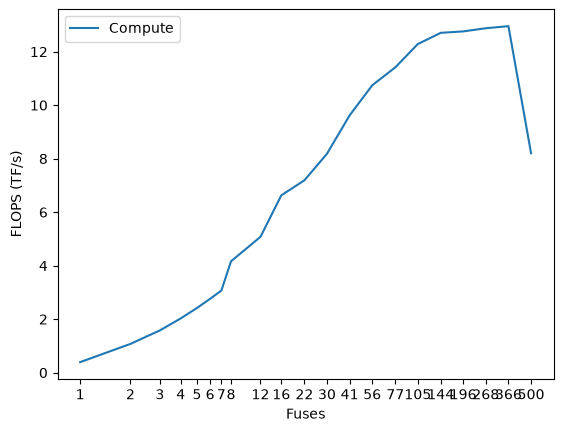

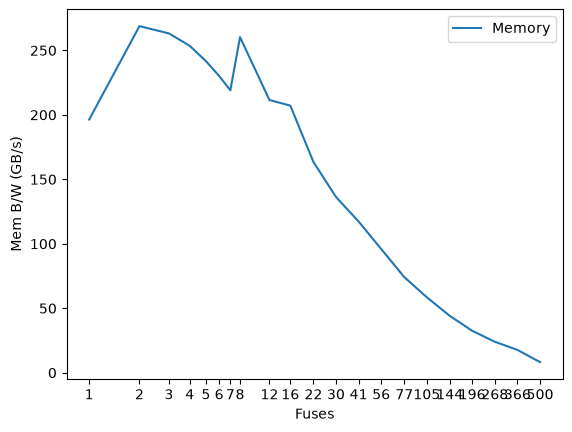

In [41]:
# SCALAR HFMA - 2 FMA on 16 bit floats, 4 flops effectively

from torch.utils.cpp_extension import load

hfma2 = load(name="hfma2", sources=["/home/nevidomy/work/ml_learning/benchmarks/hfma2.cu"],
         extra_cuda_cflags=["-O3", "-lineinfo"], verbose=True)

def mul_f_provider(repeat):
    def f(out, x):
        return hfma2.scalar(out, x, repeat)
    return f

plot_stats(
    "gpu_mul",
    runBenchmark(
        func_provider=mul_f_provider,
        inputs=torch.randn(2**26, dtype=torch.float16).cuda(),
        iterations=100,
        single_call_flops=8,
        fusion_range=[1, 500],
        steps=20,
        verbose=True,
        needOutputs=True))

In [49]:

def runMmulBenchmark(
        inputsA,            # inputs to the function (tensor on device)
        inputsB,            # inputs to the function (tensor on device)
        iterations,         # number of iterations to run per instance
        verbose=False,):
    print(f"Running matmul benchmark")
    outputs = torch.empty_like(inputsA)

    def func(a, b, out):
        torch.mm(a, b, out=out)
    # warm up
    f = torch.compile(func)

    for _ in range(5): 
        f(inputsA, inputsB, outputs)

    torch.cuda.synchronize()
    start = time.time()
    for _ in range(iterations):
        f(inputsA, inputsB, outputs)
    torch.cuda.synchronize()
    end = time.time()

    n = inputsA.shape[0]
    m = inputsB.shape[1]
    k = inputsA.shape[1]
    t_iter = (end - start) / iterations
    iter_per_sec = 1 / t_iter
    flops = iter_per_sec *  n * m * k * 2
    bytes_per_second = iter_per_sec * (inputsA.numel() * inputsA.element_size() + inputsB.numel() * inputsB.element_size() + outputs.numel() * outputs.element_size())

    print(f"MMUL: Iter/sec: {iter_per_sec:.3f}, TFLOPS: {flops * 1e-12:.2f}, Mem Gb/s: {bytes_per_second*1e-9:.2f}")

for i in range(10):
    runMmulBenchmark(torch.randn(4096, 4096, dtype=torch.float16).cuda(), torch.randn(4096, 4096, dtype=torch.float16).cuda(), 100)

Running matmul benchmark
MMUL: Iter/sec: 201.674, TFLOPS: 27.72, Mem Gb/s: 20.30
Running matmul benchmark
MMUL: Iter/sec: 206.558, TFLOPS: 28.39, Mem Gb/s: 20.79
Running matmul benchmark
MMUL: Iter/sec: 198.972, TFLOPS: 27.35, Mem Gb/s: 20.03
Running matmul benchmark
MMUL: Iter/sec: 192.862, TFLOPS: 26.51, Mem Gb/s: 19.41
Running matmul benchmark
MMUL: Iter/sec: 193.029, TFLOPS: 26.53, Mem Gb/s: 19.43
Running matmul benchmark
MMUL: Iter/sec: 193.078, TFLOPS: 26.54, Mem Gb/s: 19.44
Running matmul benchmark
MMUL: Iter/sec: 193.069, TFLOPS: 26.54, Mem Gb/s: 19.43
Running matmul benchmark
MMUL: Iter/sec: 193.082, TFLOPS: 26.54, Mem Gb/s: 19.44
Running matmul benchmark
MMUL: Iter/sec: 193.078, TFLOPS: 26.54, Mem Gb/s: 19.44
Running matmul benchmark
MMUL: Iter/sec: 193.078, TFLOPS: 26.54, Mem Gb/s: 19.44


In [35]:
import subprocess, glob, os
so = glob.glob(os.path.expanduser("~/.cache/torch_extensions/**/*.so"), recursive=True)[0]
print(subprocess.run(["cuobjdump","-sass",so], capture_output=True, text=True).stdout)



Fatbin elf code:
arch = sm_86
code version = [1,7]
host = linux
compile_size = 64bit
identifier = /home/nevidomy/work/ml_learning/benchmarks/hfma2.cu

	code for sm_86
		Function : _Z13scalar_kernelP6__halfPKS_ii
	.headerflags	@"EF_CUDA_TEXMODE_UNIFIED EF_CUDA_64BIT_ADDRESS EF_CUDA_SM86 EF_CUDA_VIRTUAL_SM(EF_CUDA_SM86)"
        /*0000*/                   IMAD.MOV.U32 R1, RZ, RZ, c[0x0][0x28] ;                                               /* 0x00000a00ff017624 */
                                                                                                                         /* 0x000fe400078e00ff */
        /*0010*/                   S2R R0, SR_CTAID.X ;                                                                  /* 0x0000000000007919 */
                                                                                                                         /* 0x000e280000002500 */
        /*0020*/                   S2R R3, SR_TID.X ;                                         